### Build a DNN using Keras with `RELU` and `ADAM`

#### Load tensorflow

In [0]:
import tensorflow as tf

#### Collect Fashion mnist data from tf.keras.datasets 

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

4423680/4422102 [==============================] - 0s 0us/step


In [3]:
x_train.shape

(60000, 28, 28)

In [4]:
x_test.shape

(10000, 28, 28)

In [5]:
y_train.shape

(60000,)

In [6]:
y_test.shape

(10000,)

#### Change train and test labels into one-hot vectors

In [0]:
# converting to 1 hot vectors 
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

#### Build the Graph

In [0]:
import numpy as np

label for each of the below image: 9
label for each of the below image: 0
label for each of the below image: 0
label for each of the below image: 3
label for each of the below image: 0
label for each of the below image: 2
label for each of the below image: 7
label for each of the below image: 2
label for each of the below image: 5
label for each of the below image: 5


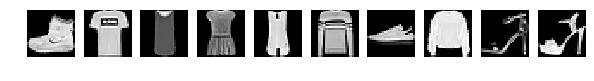

In [13]:
# visualizing the first 10 images in the dataset and their labels
%matplotlib inline
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 1))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.axis('off')
    print('label for each of the below image: %s' % (np.argmax(y_train[0:10][i])))
plt.show()

#### Initialize model, reshape & normalize data

In [0]:
#importing the required packages 
from keras.models import Sequential
from keras.layers import Dense
from keras import regularizers
from keras import optimizers

In [0]:
#Initialize Sequential model
model = tf.keras.models.Sequential()

#Reshape data from 2D to 1D -> 28x28 to 784
model.add(tf.keras.layers.Reshape((784,),input_shape=(28,28,)))

#Normalize the data
model.add(tf.keras.layers.BatchNormalization())

#### Add two fully connected layers with 200 and 100 neurons respectively with `relu` activations. Add a dropout layer with `p=0.25`

In [15]:
#Add 1st FC layer
model.add(tf.keras.layers.Dense(200, activation='relu'))
#Add 2nd FC layer
model.add(tf.keras.layers.Dense(100, activation='relu'))

W0825 15:34:02.288172 139830534330240 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [0]:
#adding dropout layer
model.add(tf.keras.layers.Dropout(0.25))

### Add the output layer with a fully connected layer with 10 neurons with `softmax` activation. Use `categorical_crossentropy` loss and `adam` optimizer and train the network. And, report the final validation.

In [0]:
#Add OUTPUT layer
model.add(tf.keras.layers.Dense(10, activation='softmax'))

# Compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [21]:
# Fit the model
model.fit(x_train,y_train,          
          validation_data=(x_test,y_test),
          epochs=10,
          batch_size=64)

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 6s 96us/sample - loss: 0.2044 - acc: 0.9215 - val_loss: 0.3349 - val_acc: 0.8933
Epoch 2/10
60000/60000 [==============================] - 6s 95us/sample - loss: 0.1950 - acc: 0.9258 - val_loss: 0.3473 - val_acc: 0.8933
Epoch 3/10
60000/60000 [==============================] - 6s 93us/sample - loss: 0.1942 - acc: 0.9262 - val_loss: 0.3516 - val_acc: 0.8917
Epoch 4/10
60000/60000 [==============================] - 6s 92us/sample - loss: 0.1842 - acc: 0.9293 - val_loss: 0.3740 - val_acc: 0.8926
Epoch 5/10
60000/60000 [==============================] - 5s 92us/sample - loss: 0.1820 - acc: 0.9297 - val_loss: 0.3668 - val_acc: 0.8950
Epoch 6/10
60000/60000 [==============================] - 6s 95us/sample - loss: 0.1743 - acc: 0.9324 - val_loss: 0.3603 - val_acc: 0.8924
Epoch 7/10
60000/60000 [==============================] - 6s 95us/sample - loss: 0.1702 - acc: 0.9349 - val_loss: 0.

In [22]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape (Reshape)            (None, 784)               0         
_________________________________________________________________
batch_normalization (BatchNo (None, 784)               3136      
_________________________________________________________________
dense (Dense)                (None, 200)               157000    
_________________________________________________________________
dense_1 (Dense)              (None, 100)               20100     
_________________________________________________________________
dropout (Dropout)            (None, 100)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1010      
Total params: 181,246
Trainable params: 179,678
Non-trainable params: 1,568
______________________________________________

In [23]:
#score on train data
score = model.evaluate(x_train, y_train, verbose=0)
score
print("The accuracy of train data is: ",score[1])

The accuracy of train data is:  0.95446664


In [24]:
#score on test data
score = model.evaluate(x_test, y_test, verbose=0)
score
print("The accuracy of test data is: ",score[1])

The accuracy of test data is:  0.8921


In [25]:
model.predict(x_test)

array([[5.9027939e-12, 1.1571975e-15, 3.5438707e-12, ..., 2.3698200e-04,
        6.8560574e-10, 9.9974173e-01],
       [3.2993608e-08, 4.6984227e-20, 9.9982029e-01, ..., 1.6628571e-22,
        7.3571201e-14, 2.1082023e-27],
       [1.4798855e-29, 1.0000000e+00, 2.4427211e-37, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       ...,
       [7.9575013e-09, 4.5443184e-23, 6.8191297e-10, ..., 2.6771996e-16,
        1.0000000e+00, 3.3536620e-22],
       [7.3958575e-29, 1.0000000e+00, 5.5942052e-34, ..., 1.7914058e-37,
        2.3231805e-31, 0.0000000e+00],
       [1.7646175e-07, 1.7628831e-13, 4.1851909e-08, ..., 9.3586892e-03,
        9.8141136e-06, 2.7837976e-07]], dtype=float32)